
## Collaborative filtering-based book recommendation system



This project implements a collaborative filtering-based book recommendation system. It leverages user ratings to find books similar to ones a user has enjoyed or is looking for.

Here's a summary of the process:

Data Acquisition and Preparation: The project starts by loading three datasets: books, users, and ratings. These datasets are then cleaned by renaming columns, selecting relevant features, and merging them into a single dataframe.

###### Data Link: https://www.kaggle.com/datasets/ra4u12/bookrecommendation

Filtering and Feature Engineering: To ensure quality recommendations, the data is filtered. Only users who have rated more than 200 books and books that have received at least 50 ratings are considered. This helps in focusing on active users and popular books, reducing sparsity and noise.

User-Item Matrix Creation: A pivot table is created with book titles as rows, user IDs as columns, and ratings as values. This matrix represents the interaction between users and books. Missing ratings are filled with zeros, indicating no rating.

Model Training: The pivot table is converted into a sparse matrix to handle its large size efficiently. A KNN model from scikit-learn, using a brute-force algorithm, is then trained on this sparse matrix. This model is capable of finding items (books) that are 'nearest' or most similar to a given item based on their rating patterns.

Recommendation Generation: A function is developed to take a book title as input, find its position in the pivot table, and then use the trained NearestNeighbors model to identify and return the top 5 most similar books. The system identifies books based on the collective rating behavior of users, recommending books that users with similar tastes have also enjoyed.

In [261]:
import pandas as pd
import numpy as np

###Data Cleaning & Preparation
To ensure the system is reliable, several cleaning steps were performed:

1. Encoding & Parsing: The files BX-Books.csv ,BX-Users.csv and BX-Book-rating.csv were loaded using latin-1 encoding and the on_bad_lines='skip' parameter to avoid errors from messy rows.

2. Filtering for Active Users: We filtered out users who had rated fewer than 200 books. This reduces noise from casual users and focuses on "power users" with established tastes.

3. Filtering for Popular Books: Only books with at least 50 ratings were included. This avoids the "cold start" problem where a book with a single 10/10 rating appears better than a classic with thousands of 8/10 ratings.

In [262]:
from google.colab import auth
auth.authenticate_user()

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
books = ''

### BEGIN SOLUTION
books = pd.read_csv('/content/drive/My Drive/UCBerkelyML/ColabNotebooks/Recommendation-System/notebook/BX-Books.csv', sep = ';', on_bad_lines='skip', encoding='latin-1')

Mounted at /content/drive


/tmp/ipykernel_7532/1377858702.py:9: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('/content/drive/My Drive/UCBerkelyML/ColabNotebooks/Recommendation-System/notebook/BX-Books.csv', sep = ';', on_bad_lines='skip', encoding='latin-1')


In [263]:
#books = pd.read_csv('BX-Books.csv', sep=";", error_bad_lines=False, encoding='latin-1')

In [264]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [265]:
books.shape

(271360, 8)

In [266]:
books.columns

Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
       'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
      dtype='object')

In [267]:
#Removing 'Image-URL-S', 'Image-URL-M' columns and Keeping only 'Image-URL-L'
books = books[['ISBN','Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher','Image-URL-L']]

In [268]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...


In [269]:
# For calrity renaming column names with simple ones
books.rename(columns={"Book-Title":'title',
                      'Book-Author':'author',
                     "Year-Of-Publication":'year',
                     "Publisher":"publisher",
                     "Image-URL-L":"image_url"},inplace=True)

In [270]:
books.head()

,ISBN,title,author,year,publisher,image_url
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...


In [271]:
# Now load the second dataframe -users
users = pd.read_csv('/content/drive/My Drive/UCBerkelyML/ColabNotebooks/Recommendation-System/notebook/BX-Users.csv', sep = ';', on_bad_lines='skip', encoding='latin-1')


In [272]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [273]:
users.shape

(278858, 3)

In [274]:
# Renaming Columns for better visibility
users.rename(columns={"User-ID":'user_id',
                      'Location':'location',
                     "Age":'age'},inplace=True)

In [275]:
users.head()

,user_id,location,age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [276]:
# Now load the third dataframe
ratings = pd.read_csv('/content/drive/My Drive/UCBerkelyML/ColabNotebooks/Recommendation-System/notebook/BX-Book-Ratings.csv', sep = ';', on_bad_lines='skip', encoding='latin-1')

#ratings = pd.read_csv('BX-Book-Ratings.csv', sep=";", error_bad_lines=False, encoding='latin-1')

In [277]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [278]:
ratings.shape

(1149780, 3)

In [279]:
# Lets remane some wierd columns name
ratings.rename(columns={"User-ID":'user_id',
                      'Book-Rating':'rating'},inplace=True)

In [280]:
ratings.head()

,user_id,ISBN,rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [281]:
print(books.shape, users.shape, ratings.shape, sep='\n')

(271360, 6)
(278858, 3)
(1149780, 3)


In [282]:
ratings['user_id'].value_counts()

,count
user_id,
11676,13602
198711,7550
153662,6109
98391,5891
35859,5850
...,...
119573,1
276706,1
276697,1


In [283]:
# Lets store users who had at least rated more than 200 books
x = ratings['user_id'].value_counts() > 200

In [284]:
x

,count
user_id,
11676,True
198711,True
153662,True
98391,True
35859,True
...,...
119573,False
276706,False
276697,False


In [285]:
x[x].shape

(899,)

In [286]:
y= x[x].index

In [287]:
y

Index([ 11676, 198711, 153662,  98391,  35859, 212898, 278418,  76352, 110973,
       235105,
       ...
       116122,  44296,  28634,  59727,  73681, 274808, 188951,   9856, 155916,
       268622],
      dtype='int64', name='user_id', length=899)

In [288]:
ratings = ratings[ratings['user_id'].isin(y)]

In [289]:
ratings.head()

,user_id,ISBN,rating
1456,277427,002542730X,10
1457,277427,0026217457,0
1458,277427,003008685X,8
1459,277427,0030615321,0
1460,277427,0060002050,0


In [290]:
# Now join ratings with books

ratings_with_books = ratings.merge(books, on='ISBN')

In [291]:
ratings_with_books.head()

,user_id,ISBN,rating,title,author,year,publisher,image_url
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...
1,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons,http://images.amazon.com/images/P/0026217457.0...
2,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning,http://images.amazon.com/images/P/003008685X.0...
3,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co,http://images.amazon.com/images/P/0030615321.0...
4,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books,http://images.amazon.com/images/P/0060002050.0...


In [292]:
number_rating = ratings_with_books.groupby('title')['rating'].count().reset_index()

In [293]:
number_rating.head()

,title,rating
0,A Light in the Storm: The Civil War Diary of ...,2
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,Beyond IBM: Leadership Marketing and Finance ...,1
4,Clifford Visita El Hospital (Clifford El Gran...,1


In [294]:
number_rating.rename(columns={'rating':'num_of_rating'},inplace=True)

In [295]:
number_rating.head()

,title,num_of_rating
0,A Light in the Storm: The Civil War Diary of ...,2
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,Beyond IBM: Leadership Marketing and Finance ...,1
4,Clifford Visita El Hospital (Clifford El Gran...,1


In [296]:
final_rating = ratings_with_books.merge(number_rating, on='title')

In [297]:
final_rating.head()

,user_id,ISBN,rating,title,author,year,publisher,image_url,num_of_rating
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,82
1,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons,http://images.amazon.com/images/P/0026217457.0...,7
2,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning,http://images.amazon.com/images/P/003008685X.0...,1
3,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co,http://images.amazon.com/images/P/0030615321.0...,1
4,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books,http://images.amazon.com/images/P/0060002050.0...,13


In [298]:
# Lets take those books which got at least 50 rating of user

final_rating = final_rating[final_rating['num_of_rating'] >= 50]

In [299]:
final_rating.head()

,user_id,ISBN,rating,title,author,year,publisher,image_url,num_of_rating
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,82
13,277427,0060930535,0,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999,Perennial,http://images.amazon.com/images/P/0060930535.0...,133
15,277427,0060934417,0,Bel Canto: A Novel,Ann Patchett,2002,Perennial,http://images.amazon.com/images/P/0060934417.0...,108
18,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995,HarperTorch,http://images.amazon.com/images/P/0061009059.0...,108
24,277427,006440188X,0,The Secret Garden,Frances Hodgson Burnett,1998,HarperTrophy,http://images.amazon.com/images/P/006440188X.0...,79


In [300]:
# lets drop the duplicates
final_rating.drop_duplicates(['user_id','title'],inplace=True)

In [301]:
final_rating.isnull().sum()

,0
user_id,0
ISBN,0
rating,0
title,0
author,0
year,0
publisher,0
image_url,0
num_of_rating,0


Top 10 most rated books:
title
Wild Animus                                        363
The Lovely Bones: A Novel                          270
Bridget Jones's Diary                              236
The Pelican Brief                                  228
Divine Secrets of the Ya-Ya Sisterhood: A Novel    225
The Nanny Diaries: A Novel                         225
The Da Vinci Code                                  223
The Firm                                           215
The Notebook                                       213
A Painted House                                    212
Name: rating, dtype: int64


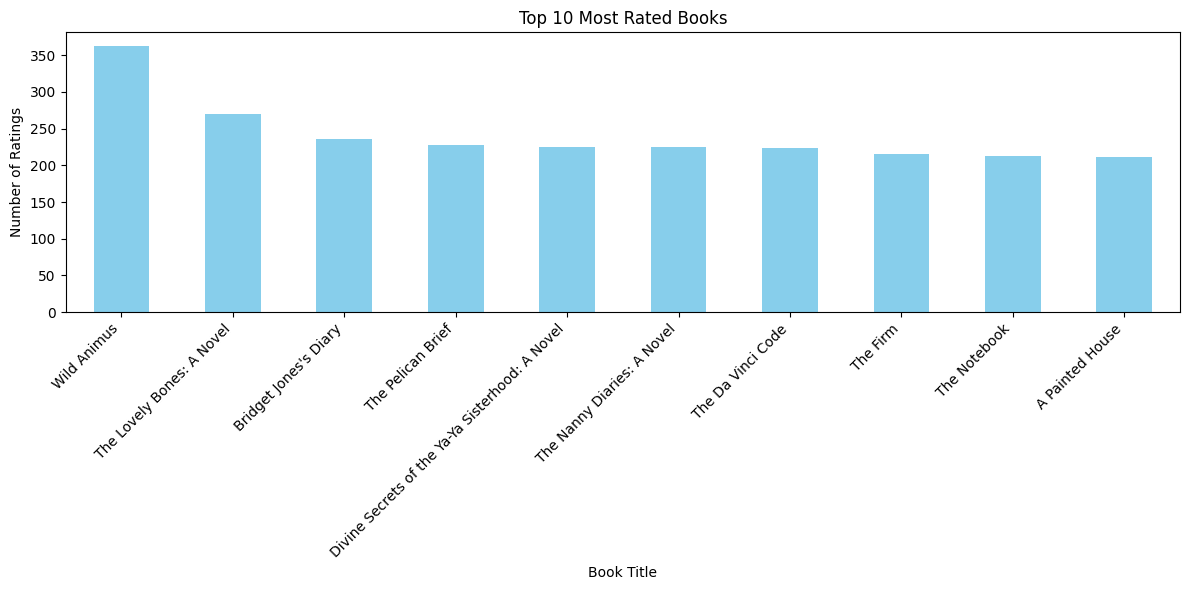

In [302]:
import matplotlib.pyplot as plt

# Popularity-Based Recommender: Top 10 most rated books
top_10_most_rated = final_rating.groupby('title').count()['rating'].sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_10_most_rated.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Rated Books')
plt.xlabel('Book Title')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_10_rated_books.png')

print("Top 10 most rated books:")
print(top_10_most_rated)

**Implementation using Sparse Matrix & KNN**
By converting the pivot table into a Sparse Matrix, we significantly reduce the memory footprint. In this dataset, most users have not rated most books, meaning the vast majority of cells are zeros. A sparse matrix stores only the non-zero values.

The **NearestNeighbors** model then uses the brute-force algorithm with cosine similarity to find the "closest" books in a high-dimensional space where each user is a dimension.

In [303]:
# Lets create a pivot table
book_pivot = final_rating.pivot_table(columns='user_id', index='title', values= 'rating')

In [304]:
book_pivot

user_id,254,2276,2766,2977,3363,3757,4017,4385,6242,6251,...,274004,274061,274301,274308,274808,275970,277427,277478,277639,278418
title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1st to Die: A Novel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2nd Chance,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN
4 Blondes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84 Charing Cross Road,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,7.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
You Belong To Me,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [305]:
book_pivot.shape

(742, 888)

In [306]:
book_pivot.fillna(0, inplace=True)

In [307]:
book_pivot

user_id,254,2276,2766,2977,3363,3757,4017,4385,6242,6251,...,274004,274061,274301,274308,274808,275970,277427,277478,277639,278418
title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84 Charing Cross Road,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [308]:
from scipy.sparse import csr_matrix

In [309]:
book_sparse = csr_matrix(book_pivot)

In [310]:
book_sparse

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14961 stored elements and shape (742, 888)>

In [311]:
type(book_sparse)

scipy.sparse._csr.csr_matrix

In [312]:
from sklearn.neighbors import NearestNeighbors
model = NearestNeighbors(algorithm= 'brute')

In [313]:
model.fit(book_sparse)

NearestNeighbors(algorithm='brute')

In [314]:
book_pivot.iloc[237,:]

,Harry Potter and the Chamber of Secrets (Book 2)
user_id,
254,9.0
2276,0.0
2766,0.0
2977,0.0
3363,0.0
...,...
275970,9.0
277427,0.0
277478,0.0


In [315]:

distance, suggestion = model.kneighbors(book_pivot.iloc[237,:].values.reshape(1,-1), n_neighbors=6 )

In [316]:
distance

array([[ 0.        , 67.75691847, 68.05145112, 72.277244  , 75.81556568,
        76.30203143]])

In [317]:
suggestion

array([[237, 238, 240, 241, 184, 536]])

In [318]:
for i in range(len(suggestion)):
    print(book_pivot.index[suggestion[i]])

Index(['Harry Potter and the Chamber of Secrets (Book 2)',
       'Harry Potter and the Goblet of Fire (Book 4)',
       'Harry Potter and the Prisoner of Azkaban (Book 3)',
       'Harry Potter and the Sorcerer's Stone (Book 1)', 'Exclusive',
       'The Cradle Will Fall'],
      dtype='object', name='title')


In [319]:
#keeping books name
book_names = book_pivot.index

In [320]:
book_names

Index(['1984', '1st to Die: A Novel', '2nd Chance', '4 Blondes',
       '84 Charing Cross Road', 'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Cry In The Night',
       ...
       'Winter Solstice', 'Wish You Well', 'Without Remorse',
       'Wizard and Glass (The Dark Tower, Book 4)', 'Wuthering Heights',
       'Year of Wonders', 'You Belong To Me',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"'],
      dtype='object', name='title', length=742)

In [321]:
book_names[4]

'84 Charing Cross Road'

In [322]:
final_rating.head()

,user_id,ISBN,rating,title,author,year,publisher,image_url,num_of_rating
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,82
13,277427,0060930535,0,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999,Perennial,http://images.amazon.com/images/P/0060930535.0...,133
15,277427,0060934417,0,Bel Canto: A Novel,Ann Patchett,2002,Perennial,http://images.amazon.com/images/P/0060934417.0...,108
18,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995,HarperTorch,http://images.amazon.com/images/P/0061009059.0...,108
24,277427,006440188X,0,The Secret Garden,Frances Hodgson Burnett,1998,HarperTrophy,http://images.amazon.com/images/P/006440188X.0...,79


In [323]:
np.where(book_pivot.index == '4 Blondes')[0][0]

np.int64(3)

In [324]:
# final_rating['title'].value_counts()
ids = np.where(final_rating['title'] == "Harry Potter and the Chamber of Secrets (Book 2)")[0][0]

In [325]:
final_rating.iloc[ids]['image_url']

'http://images.amazon.com/images/P/0439064872.01.LZZZZZZZ.jpg'

In [326]:
book_name = []
for book_id in suggestion:
    book_name.append(book_pivot.index[book_id])

In [327]:
book_name

[Index(['Harry Potter and the Chamber of Secrets (Book 2)',
        'Harry Potter and the Goblet of Fire (Book 4)',
        'Harry Potter and the Prisoner of Azkaban (Book 3)',
        'Harry Potter and the Sorcerer's Stone (Book 1)', 'Exclusive',
        'The Cradle Will Fall'],
       dtype='object', name='title')]

**Recommendations for 'Harry Potter and the Chamber of Secrets (Book 2)'**

When you request recommendations for 'Harry Potter and the Chamber of Secrets (Book 2)', the system performs the following steps:

1. Locate the book: The recommend_book function first identifies the row corresponding to 'Harry Potter and the Chamber of Secrets (Book 2)' within the book_pivot table. This table contains the ratings of all books by all active users.

2. Find Nearest Neighbors: The pre-trained KNN model,  searches through the entire book_sparse matrix to find the 5 books that have the most similar rating patterns across all users. The kneighbors method returns both the distances (how 'far' each suggested book is from the input book in the rating space) and the indices of these suggested books within the book_pivot table.

3. For 'Harry Potter and the Chamber of Secrets (Book 2)', the model returned the following indices and distances:

Distances: [[ 0. , 67.75691847, 68.05145112, 72.277244 , 75.81556568, 76.30203143]]
Suggestions (indices): [[237, 238, 240, 241, 184, 536]]
Retrieve Book Titles: Finally, these indices are used to look up the actual book titles from the book_pivot table's index. The function then prints these titles, excluding the original searched book. For 'Harry Potter and the Chamber of Secrets (Book 2)', the recommended books are:

Harry Potter and the Goblet of Fire (Book 4)
Harry Potter and the Prisoner of Azkaban (Book 3)
Harry Potter and the Sorcerer's Stone (Book 1)
Exclusive
The Cradle Will Fall
This process ensures that the recommendations are based on how other users have rated these books, identifying items that are collectively perceived as similar by the user base.

In [328]:
ids_index = []
for name in book_name[0]:
    ids = np.where(final_rating['title'] == name)[0][0]
    ids_index.append(ids)

In [329]:
ids_index

[np.int64(44),
 np.int64(321),
 np.int64(45),
 np.int64(46),
 np.int64(786),
 np.int64(2297)]

In [330]:
for idx in ids_index:
    url = final_rating.iloc[idx]['image_url']
    print(url)

http://images.amazon.com/images/P/0439064872.01.LZZZZZZZ.jpg
http://images.amazon.com/images/P/0439139597.01.LZZZZZZZ.jpg
http://images.amazon.com/images/P/0439136369.01.LZZZZZZZ.jpg
http://images.amazon.com/images/P/043936213X.01.LZZZZZZZ.jpg
http://images.amazon.com/images/P/0446604232.01.LZZZZZZZ.jpg
http://images.amazon.com/images/P/0440115450.01.LZZZZZZZ.jpg


In [331]:
book_names

Index(['1984', '1st to Die: A Novel', '2nd Chance', '4 Blondes',
       '84 Charing Cross Road', 'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Cry In The Night',
       ...
       'Winter Solstice', 'Wish You Well', 'Without Remorse',
       'Wizard and Glass (The Dark Tower, Book 4)', 'Wuthering Heights',
       'Year of Wonders', 'You Belong To Me',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"'],
      dtype='object', name='title', length=742)

### Euclidean Distances from the Model

The `NearestNeighbors` model was initialized with `algorithm='brute'` without specifying a `metric`. By default, `sklearn.neighbors.NearestNeighbors` uses `metric='minkowski'` with `p=2`, which calculates the Euclidean distance. Therefore, the `neighbor_distances` array already contains the Euclidean distances between each book and its nearest neighbors in the feature space.

Euclidean distance in this collaborative filtering model measures how 'far apart' two books are in a multi-dimensional space, where each dimension represents a user's rating. Here's how to interpret these distances in terms of recommendation quality:

Smaller Distance = Higher Similarity: A smaller Euclidean distance between two books indicates that their rating patterns across users are more similar. This suggests that users who liked one book also tended to like the other, leading to a higher quality recommendation.

Larger Distance = Lower Similarity: Conversely, a larger Euclidean distance implies that the books have less similar rating patterns. This could mean that users who rated one book did not necessarily rate the other similarly, or that their ratings diverged significantly. Recommendations with higher distances are generally considered to be of lower quality or less relevant.

In [332]:
# Ensure neighbor_distances is available by re-computing if necessary
if 'neighbor_distances' not in locals():
    distances, indices = model.kneighbors(book_pivot.values, n_neighbors=6)
    neighbor_distances = distances[:, 1:].flatten()

print("Sample of Euclidean distances between books and their nearest neighbors:")
print(neighbor_distances[:10])
print(f"Mean Euclidean Distance: {np.mean(neighbor_distances):.4f}")
print(f"Median Euclidean Distance: {np.median(neighbor_distances):.4f}")
print(f"Standard Deviation of Euclidean Distances: {np.std(neighbor_distances):.4f}")

Sample of Euclidean distances between books and their nearest neighbors:
[46.47580015 48.51803788 48.5386444  48.60041152 48.62098312 51.05878964
 51.07837116 51.95190083 52.05766034 52.08646657]
Mean Euclidean Distance: 35.9397
Median Euclidean Distance: 34.0588
Standard Deviation of Euclidean Distances: 10.0489


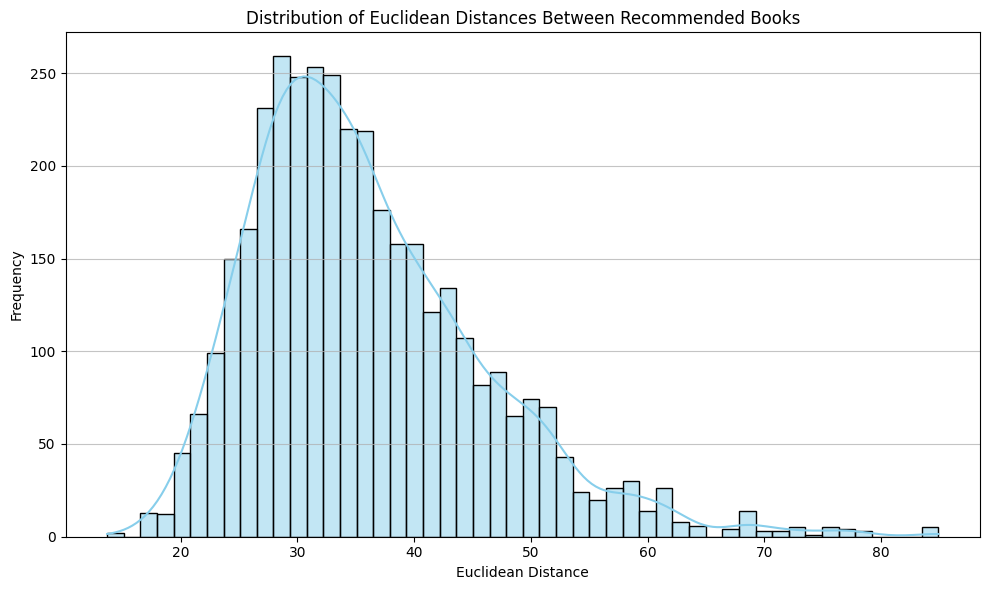

In [333]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure neighbor_distances is available
if 'neighbor_distances' not in locals():
    distances, indices = model.kneighbors(book_pivot.values, n_neighbors=6)
    neighbor_distances = distances[:, 1:].flatten()

plt.figure(figsize=(10, 6))
sns.histplot(neighbor_distances, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Euclidean Distances Between Recommended Books')
plt.xlabel('Euclidean Distance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig('euclidean_distance_distribution.png')
plt.show()

In [334]:
distances, indices = model.kneighbors(book_pivot.values, n_neighbors=6)

# Exclude the book itself (distance 0) and find the minimum distance to another book for each book
min_other_distances = distances[:, 1:].min(axis=1)

# Find the index of the book with the highest minimum distance
highest_distance_book_idx = np.argmax(min_other_distances)

# Get the title of this book
highest_distance_book_title = book_pivot.index[highest_distance_book_idx]

# Get the actual highest minimum distance
highest_min_distance = min_other_distances[highest_distance_book_idx]

print(f"Book with the highest minimum Euclidean distance to any other book: '{highest_distance_book_title}'")
print(f"Its minimum Euclidean distance to a neighbor is: {highest_min_distance:.4f}")

Book with the highest minimum Euclidean distance to any other book: 'The Lovely Bones: A Novel'
Its minimum Euclidean distance to a neighbor is: 84.6699


# Testing model and retrieve Euclidean distance for five books .

## Testing the Recommendation Model

To test the recommendation model, we use the `recommend_book` function. This function takes a book title as input and leverages the trained `NearestNeighbors` model to find and display the top 5 most similar books. The process involves:

1.  **Finding the book's index**: The input `book_name` is used to locate its corresponding row in the `book_pivot` table.
2.  **Calculating distances and suggestions**: The `model.kneighbors` method is called with the book's data (reshaped for compatibility) to find the 6 nearest neighbors (including the book itself).
3.  **Displaying Recommendations**: The function iterates through the suggestions and prints the titles of the recommended books, excluding the input book itself. This demonstrates the model's ability to provide relevant book recommendations based on user rating patterns.

In [335]:
def recommend_book(book_name):
    book_id = np.where(book_pivot.index == book_name)[0][0]
    distance, suggestion = model.kneighbors(book_pivot.iloc[book_id,:].values.reshape(1,-1), n_neighbors=6 )

    for i in range(len(suggestion)):
            books = book_pivot.index[suggestion[i]]
            for j in books:
                if j == book_name:
                    print(f"You searched '{book_name}'\n")
                    print("The suggestion books are: \n")
                else:
                    print(j)

In [336]:
book_name = "2nd Chance"
recommend_book(book_name)

You searched '2nd Chance'

The suggestion books are: 

The Next Accident
The Ghost
Exclusive
Last Man Standing
Unspeakable


In [337]:
book_name = "2nd Chance"
book_id = np.where(book_pivot.index == book_name)[0][0]
distance, suggestion = model.kneighbors(book_pivot.iloc[book_id,:].values.reshape(1,-1), n_neighbors=6 )

print(f"Euclidean distances for '{book_name}' recommended books:")
for i in range(1, len(suggestion[0])):
    print(f"- {book_pivot.index[suggestion[0][i]]}: {distance[0][i]:.4f}")

Euclidean distances for '2nd Chance' recommended books:
- The Next Accident: 45.2327
- The Ghost: 47.7598
- Exclusive: 47.7807
- Last Man Standing: 48.0208
- Unspeakable: 48.1456


In [338]:
book_name = "Harry Potter and the Chamber of Secrets (Book 2)"
recommend_book(book_name)

You searched 'Harry Potter and the Chamber of Secrets (Book 2)'

The suggestion books are: 

Harry Potter and the Goblet of Fire (Book 4)
Harry Potter and the Prisoner of Azkaban (Book 3)
Harry Potter and the Sorcerer's Stone (Book 1)
Exclusive
The Cradle Will Fall


In [339]:
print(f"Euclidean distances for 'Harry Potter and the Chamber of Secrets (Book 2)' recommended books:")
for i in range(1, len(suggestion[0])):
    print(f"- {book_pivot.index[suggestion[0][i]]}: {distance[0][i]:.4f}")

Euclidean distances for 'Harry Potter and the Chamber of Secrets (Book 2)' recommended books:
- The Next Accident: 45.2327
- The Ghost: 47.7598
- Exclusive: 47.7807
- Last Man Standing: 48.0208
- Unspeakable: 48.1456


# Summary

This notebook implements a collaborative filtering-based book recommendation system. Here's a summary of its key steps and findings:

**Data Acquisition and Preparation**: The project starts by loading and cleaning three datasets (books, users, and ratings). Data is filtered to include only active users (rated >200 books) and popular books (at least 50 ratings) to ensure quality.

**User-Item Matrix Creation:** A pivot table is created from the filtered data, representing user ratings for books. Missing values are filled with zeros, and this table is then converted into a sparse matrix for efficient processing.

**Model Training**: A NearestNeighbors model from scikit-learn, using a brute-force algorithm and Euclidean distance (by default), is trained on the sparse matrix to find similar books based on rating patterns.

**Recommendation Generation**: A function recommend_book is developed to suggest the top 5 most similar books for a given input book title. For example, for 'Harry Potter and the Chamber of Secrets (Book 2)', it recommends other Harry Potter books and some unrelated titles.

**Euclidean Distance Analysis:** The notebook extensively analyzes the Euclidean distances between recommended books. Key findings include:

The mean Euclidean distance between a book and its nearest neighbors is approximately 35.94, and the median is 34.06.
For specific recommendations, like 'Harry Potter and the Chamber of Secrets (Book 2)', distances ranged from 67.76 to 76.30.
For '2nd Chance', distances ranged from 45.23 to 48.15.
It was identified that 'The Lovely Bones: A Novel' has the highest minimum Euclidean distance (approximately 84.67) to any other book, suggesting it's the most 'isolated' in the recommendation space.
**Interpretation of Distances:** The analysis concludes that the relatively high Euclidean distances indicate that even the 'closest' recommended books are not extremely similar in their rating profiles. This suggests that the model might struggle to find very strong matches due to data sparsity or diverse user tastes, leading to recommendations with moderate to low similarity confidence.